# Example usage of PyLiPD and Pyleoclim

Uses the extemely unstable Pyleoclim v1.0.0b, that redefines the Series class to accomodate geolocation. 

To install:

`pip install git+https://github.com/LinkedEarth/Pyleoclim_util.git@new-objects`

## Working with Series Objects with geolocation

The Series object now takes the following arguments:

* time (mandatory): value for the time axis
* value (mandatory): value for the y-axis
* time_name (optional): Name of the time axis
* value_name (optional): Name of the y-axis
* value_unit (optional): Units for the y-axis
* time_unit (optional): Units for the time axis
* label (optional): A label for the data. Users should be free to change this name for plots
* lat (optional): latitude
* lon (optional): longitude
* dataset_name (optional): Could be the same as label but for Lipd compliant datasets, this will need to stay fix so we can go fetch more metadata (e.g., ensemble tables)
* archiveType (optional): Name of the proxy archive
* mean (optional): Mean of the dataset (this is a leftover from needing that value after some transformations. Safe to remove?)
* clean_ts (optional): Whether to remove NaNs and reorder the Series
* log (optional): a dictionary of transformation
* verbose (optional)

Let's create a simple timeseries for illustration purposes:

(<Figure size 1000x400 with 1 Axes>,
 <AxesSubplot: xlabel='Year [CE]', ylabel='temperature [degC]'>)

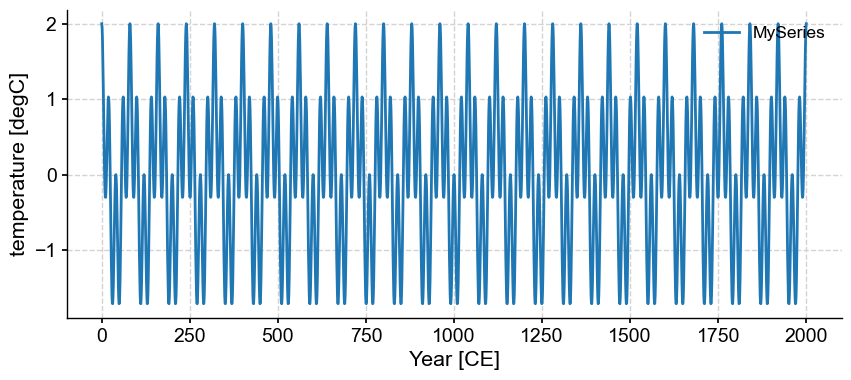

In [1]:
import pyleoclim as pyleo
import numpy as np

# Let's first play with a "perfect" series
freqs=[1/20,1/80]
time=np.arange(2001)
signals=[]
for freq in freqs:
    signals.append(np.cos(2*np.pi*freq*time))
signal=sum(signals)

ts=pyleo.Series(time=time,value=signal,value_name='temperature', 
                time_name='Year', value_unit='degC', time_unit='CE', label='MySeries')

ts.plot()

Note that we didn't specify geographical coordinates. Let's see what happens if we try to map it:

In [2]:
ts.map()

ValueError: Latitude and longitude should be provided for mapping

Let's add coordinates:

(<Figure size 640x480 with 1 Axes>, <GeoAxesSubplot: >)

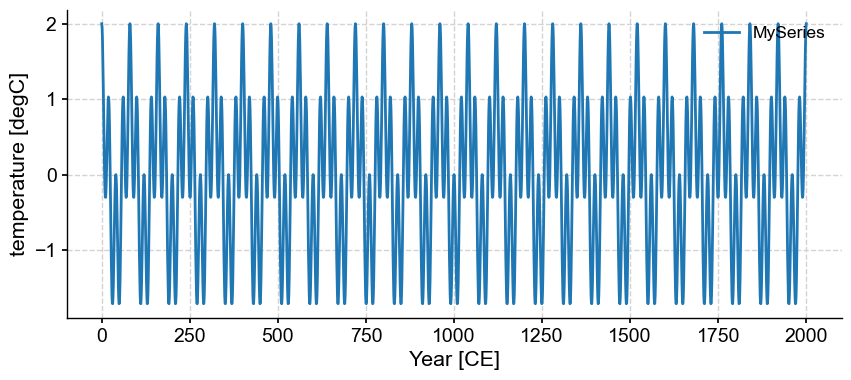

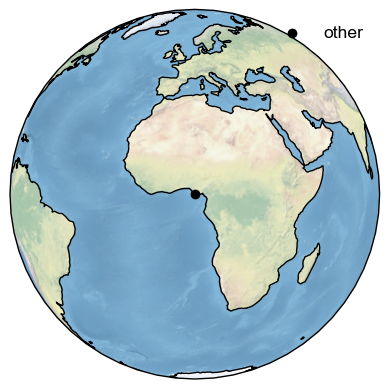

In [3]:
ts_m=pyleo.Series(time=time,value=signal,value_name='temperature', 
                time_name='Year', value_unit='degC', time_unit='CE', label='MySeries', lat=4.5, lon=6)
ts_m.plot()
ts_m.map()

Since the archiveType is not specified, defaults to the old "other" for determining color/marker.

Let's add an archiveType:

(<Figure size 640x480 with 1 Axes>, <GeoAxesSubplot: >)

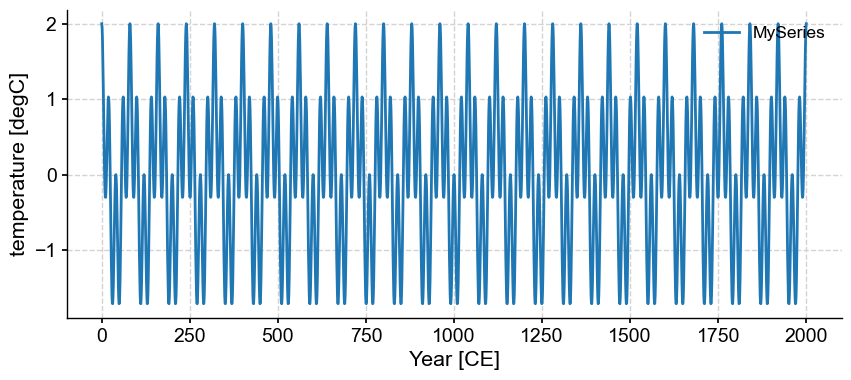

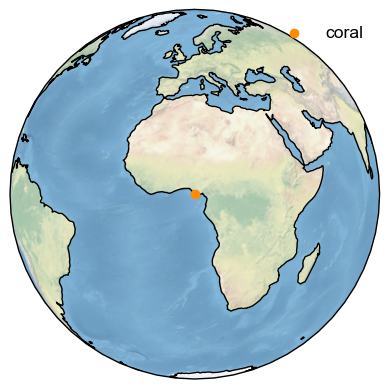

In [4]:
ts_m2=pyleo.Series(time=time,value=signal,value_name='temperature', 
                time_name='Year', value_unit='degC', time_unit='CE', label='MySeries', lat=4.5, lon=6, archiveType='coral')
ts_m2.plot()
ts_m2.map()

Works for the map, which was always enabled to work with the color scheme but if we want to keep this (instead of relying on plottig defaults), then we need to rewrite some of the plotting functions.

## Loading from a LiPD-compliant file

### Exploring PyLiPD functionalities

Let's open a sample of the Euro2k database

In [17]:
from lipd import LiPD, convert_to_rdf
import json
import os

In [18]:
lipd = LiPD()

In [19]:
lipd.load_local_from_dir('./data/')

Loading 31 LiPD files
Conversion to RDF done..
Loading RDFs into graph
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpgum1j0tr
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp4k72qtr4
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpegpi_z2_
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp8x3fxwup
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp0v10yoss
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp_dwuqchh
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpy5q83dxe
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmppvlxfh5t
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpuuphp1ej
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpb0xr2vo_
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp5p6iih_m
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpvfk6f387
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpwryiv5vb
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmpoyxp3lmq
/var/folders/xj/p7h9764x7cx0by8547l04rrr0000gn/T/tmp74qldpfo
/var/folders/x

In [20]:
datasets = lipd.get_datasets(data_only=False)

We would need APIs to query datasets, and flatten the dictionaries out. Doing it manually for illustration purposes.

In this case, we will only recover the following information:
- datasetname
- archivetype
- lat/lon

In [ ]:
datasets[0].keys()

dict_keys(['includesPaleoData', 'publishedIn', 'studyName', 'type', 'lipdVersion', 'proxyArchiveType', 'author', 'collectedFrom', 'hasLink', 'name', 'googleMetadataWorksheet', 'hasUrl', 'hasSpreadsheetLink', 'createdBy', 'googleDataURL', 'id', 'includesChronData'])

Note: 'proxyArchiveType' should be 'archiveType'

Really need some utilities/SPARQL capabilities to create the Series objects

### Using the GraphDB and SPARQL queries to simplify the problem.

In [5]:
import json
import requests
import pandas as pd
import io

In [6]:
url='https://linkedearth.graphdb.mint.isi.edu/repositories/LiPDVerse2'

query = """
PREFIX le: <http://linked.earth/ontology#>
PREFIX wgs: <http://www.w3.org/2003/01/geo/wgs84_pos#>
select ?dsname ?varname ?val ?varunits ?timevarname ?timeval ?timeunits ?lat ?lon ?archiveType where { 
	?ds le:name ?dsname. 
    VALUES ?dsname {"CO93COTW"}
    ?ds le:proxyArchiveType ?archiveType.
    ?ds le:collectedFrom ?loc.
    ?loc wgs:lat ?lat.
    ?loc wgs:long ?lon.
    
    ?data le:foundInMeasurementTable ?table .
	?table le:includesVariable ?var .
    
    ?var le:name ?varname .  
    ?var le:hasValues ?val .    
    OPTIONAL { ?var le:hasUnits ?varunits } .
    
    ?table le:includesVariable ?timevar .
    ?timevar le:name ?timevarname .
    VALUES ?timevarname {"year" "age"} .
    ?timevar le:hasValues ?timeval .
    ?timevar le:hasUnits ?timeunits .
    
} limit 100 
"""

response = requests.post(url, data = {'query': query})

data = io.StringIO(response.text)
df = pd.read_csv(data, sep=",")

df['val']=df['val'].apply(lambda row : json.loads(row) if isinstance(row, str) else row)
df['timeval']=df['timeval'].apply(lambda row : json.loads(row) if isinstance(row, str) else row)


In [7]:
df

,dsname,varname,val,varunits,timevarname,timeval,timeunits,lat,lon,archiveType
0,CO93COTW,MXD,"[0.968, 0.962, 1.013, 0.95, 1.008, 0.952, 1.02...",NaN,year,"[1568, 1569, 1570, 1571, 1572, 1573, 1574, 157...",AD,1.4167,173.0333,Coral
1,CO93COTW,segment,"[416.0, 416.0, 416.0, 416.0, 416.0, 416.0, 413...",NaN,year,"[1568, 1569, 1570, 1571, 1572, 1573, 1574, 157...",AD,1.4167,173.0333,Coral
2,CO93COTW,EPS,"[0.765, 0.765, 0.765, 0.765, 0.765, 0.765, 0.7...",NaN,year,"[1568, 1569, 1570, 1571, 1572, 1573, 1574, 157...",AD,1.4167,173.0333,Coral
3,CO93COTW,sampleCount,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",count,year,"[1568, 1569, 1570, 1571, 1572, 1573, 1574, 157...",AD,1.4167,173.0333,Coral
4,CO93COTW,SE,"[0.0741, 0.0741, 0.0741, 0.0741, 0.0741, 0.074...",NaN,year,"[1568, 1569, 1570, 1571, 1572, 1573, 1574, 157...",AD,1.4167,173.0333,Coral
...,...,...,...,...,...,...,...,...,...,...
95,CO93COTW,year,"[1126.285, 958.181, 823.697, 655.591, 487.486,...",AD,year,"[1126.285, 958.181, 823.697, 655.591, 487.486,...",AD,1.4167,173.0333,Coral
96,CO93COTW,Actinoptychus spp.,"[0, 0, 10409, 5879, 0, 23229, 0, 18493, 0, 262...",unitless,year,"[1126.285, 958.181, 823.697, 655.591, 487.486,...",AD,1.4167,173.0333,Coral
97,CO93COTW,Cyclotella spp.,"[100915, 59524, 46838, 58789, 11794, 46458, 32...",unitless,year,"[1126.285, 958.181, 823.697, 655.591, 487.486,...",AD,1.4167,173.0333,Coral
98,CO93COTW,Coscinodiscus spp.,"[44150, 44643, 5204, 41152, 11794, 30972, 5427...",unitless,year,"[1126.285, 958.181, 823.697, 655.591, 487.486,...",AD,1.4167,173.0333,Coral


In [8]:
df.varname.unique()

array(['MXD', 'segment', 'EPS', 'sampleCount', 'SE', 'density', 'corrs',
       'RBar', 'year', 'core', 'SD', 'ARS', 'residual', 'ringWidth',
       'trsgi', 'blueIntensity', 'd18O', 'Th230_U238activity', 'weight',
       'depthbottomCs', 'd234U_error', 'depthUTh', 'age', 'depthtopCs',
       'dU234initial', 'dU234i_error', 'depthtopPb', 'AgeCorr_error',
       'd234U', 'Th230_Th232ratio', 'Cs137gamactivity', 'analysisYear',
       'AgeUncorr_error', 'Th232_error', 'U238_error', 'U238',
       'Cs137_error', 'AgeUncorrected', 'Thratio_error', 'depthbottomPb',
       'SampleID', 'Pb210excess', 'U_Thactivity_error', 'Th232',
       'Pb210_error', 'SumDiatoms', 'Paralia sulcata',
       'Thalassiosira spp.', 'CAL', 'Azpeitia nodulifer',
       'Acinocyclus. curvatulus', 'Chaetoceros spores',
       'Stephanopyxis spp.', 'Roperia tesselata', 'Az. tabularis',
       'A. octonarius', 'Actinoptychus spp.', 'Cyclotella spp.',
       'Coscinodiscus spp.', 'Hemidiscus cuneiformis'], dtype=object

We have both chron and paleo tables returned in this query (we will need to enable users to ask for either or both). Also constains both year and age (most likely related to the chron table).

<div class="alert alert-block alert-warning">
We do need to track the table number from which each of these variables are coming from.
</div>

Let's grab the d18O data:

In [9]:
df_d18O=df[df['varname']=='d18O']

df_d18O

,dsname,varname,val,varunits,timevarname,timeval,timeunits,lat,lon,archiveType
30,CO93COTW,d18O,"[-6.14, -6.48, -6.05, -6.18, -5.83, -5.91, -5....",permil,year,"[660, 650, 640, 630, 620, 610, 590, 580, 570, ...",AD,1.4167,173.0333,Coral
60,CO93COTW,d18O,"[-5.16, -4.45, -4.88, -5.25, -4.9, -5.3, -5.69...",permil,year,"[-4260, -4260, -4270, -4270, -4280, -4290, -42...",AD,1.4167,173.0333,Coral
62,CO93COTW,d18O,"[-8.69, -8.69, -8.76, -8.77, -8.87, -8.98, -9....",permil,year,"[854, 855, 856, 857, 858, 859, 860, 861, 862, ...",AD,1.4167,173.0333,Coral


Let's grab the first one as an example:

(<Figure size 640x480 with 1 Axes>, <GeoAxesSubplot: >)

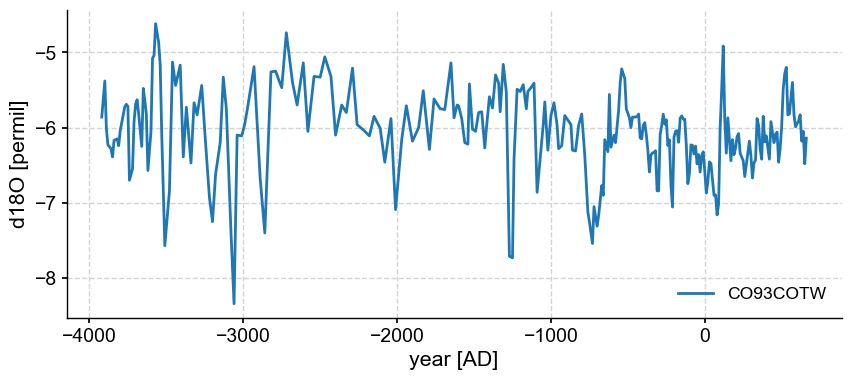

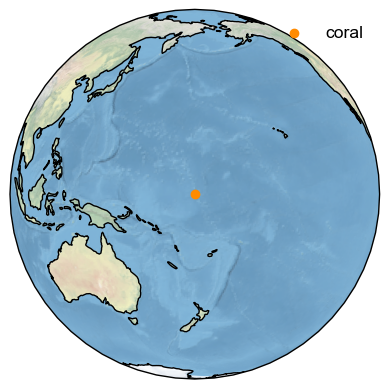

In [16]:
ts_lipd=pyleo.Series(time=df_d18O['timeval'].iloc[0],
                     value=df_d18O['val'].iloc[0], 
                     value_name = df_d18O['varname'].iloc[0],
                     time_name=df_d18O['timevarname'].iloc[0], 
                     value_unit=df_d18O['varunits'].iloc[0], 
                     time_unit=df_d18O['timeunits'].iloc[0], 
                     label=df_d18O['dsname'].iloc[0], 
                     lat=df_d18O['lat'].iloc[0], 
                     lon=df_d18O['lon'].iloc[0],
                     archiveType=df_d18O['archiveType'].iloc[0],
                    dataset_name = df_d18O['dsname'].iloc[0])
ts_lipd.plot()
ts_lipd.map()